# I2C Example

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from pioemu import conditions, emulate, State
from adafruit_pioasm import Program
from collections import deque

## Introduction

This notebook demonstrates the emulation of a PIO program for the Raspberry Pi Foundation's RP2040 Microcontroller. The PIO program is a SPI transciever

## PIO Program

Below is the PIO program that will be emulated. Try changing it and observing the results!

In [92]:
asm = Program('''
; Adapted from https://github.com/raspberrypi/pico-examples/blob/master/pio/i2c/i2c.pio
; Copyright (c) 2020 Raspberry Pi (Trading) Ltd.
;
; SPDX-License-Identifier: BSD-3-Clause
;
.pio_version 0 // only requires PIO version 0

.program i2c
.side_set 1 opt pindirs

; TX Encoding:
; | 15:10 | 9     | 8:1  | 0   |
; | Instr | Final | Data | NAK |
;
; If Instr has a value n > 0, then this FIFO word has no
; data payload, and the next n + 1 words will be executed as instructions.
; Otherwise, shift out the 8 data bits, followed by the ACK bit.
;
; The Instr mechanism allows stop/start/repstart sequences to be programmed
; by the processor, and then carried out by the state machine at defined points
; in the datastream.
;
; The "Final" field should be set for the final byte in a transfer.
; This tells the state machine to ignore a NAK: if this field is not
; set, then any NAK will cause the state machine to halt and interrupt.
;
; Autopull should be enabled, with a threshold of 16.
; Autopush should be enabled, with a threshold of 8.
; The TX FIFO should be accessed with halfword writes, to ensure
; the data is immediately available in the OSR.
;
; Pin mapping:
; - Input pin 0 is SDA, 1 is SCL (if clock stretching used)
; - Jump pin is SDA
; - Side-set pin 0 is SCL
; - Set pin 0 is SDA
; - OUT pin 0 is SDA
; - SCL must be SDA + 1 (for wait mapping)
;
; The OE outputs should be inverted in the system IO controls!
; (It's possible for the inversion to be done in this program,
; but costs 2 instructions: 1 for inversion, and one to cope
; with the side effect of the MOV on TX shift counter.)

public do_nack:
    jmp y-- entry_point        ; Continue if NAK was expected
    irq wait 0 rel             ; Otherwise stop, ask for help

public do_byte:
    set x, 7                   ; Loop 8 times
public bitloop:
    out pindirs, 1         [7] ; Serialise write data (all-ones if reading)
    nop             side 1 [2] ; SCL rising edge
    wait 1 pin, 1          [4] ; Allow clock to be stretched
    in pins, 1             [7] ; Sample read data in middle of SCL pulse
    jmp x-- bitloop side 0 [7] ; SCL falling edge

    ; Handle ACK pulse
    out pindirs, 1         [7] ; On reads, we provide the ACK.
    nop             side 1 [7] ; SCL rising edge
    wait 1 pin, 1          [7] ; Allow clock to be stretched
    jmp pin do_nack side 0 [2] ; Test SDA for ACK/NAK, fall through if ACK

public entry_point:
.wrap_target
    out x, 6                   ; Unpack Instr count
    out y, 1                   ; Unpack the NAK ignore bit
    jmp !x do_byte             ; Instr == 0, this is a data record.
    out null, 32
    set y, 1
    jmp x!=y, do_stop
public do_start:
    set pins, 1 side 1 [3]
    set pins, 0        [3]
    nop,        side 0 [7]
    nop,        side 1 [7]
    jmp entry_point
public do_stop:
    set pins, 0 side 0 [7]
    nop,        side 1 [7]
    set pins, 1        [7]
.wrap
''')

program = asm.assembled
print(program)
print(asm.pio_kwargs)

array('H', [140, 49200, 57383, 26497, 47682, 9377, 18177, 5955, 26497, 48962, 10145, 4800, 24614, 24641, 34, 24672, 57409, 183, 64257, 64256, 46914, 48962, 12, 63232, 65280, 65281])
{'sideset_enable': True, 'sideset_pin_count': 1, 'sideset_pindirs': True, 'wrap': 25, 'wrap_target': 12}


## Emulation

In [93]:
class Clocked:
    def __init__(self, data,bits):
        self.data = data
        self.i = bits
        self.prev = 0
    def next(self, state:State) -> int:
        clk = state.pin_values & 4
        if clk and not self.prev:
            self.i -= 1
        self.prev = clk
        mask = 1<<self.i if self.i>=0 else 0
        return 2 if self.data & mask else 0

def always_high(state:State) -> int:
    return 3

i2cstart = 0x1<<10
i2cstop = 0x2<<10
tx_bytes = [i2cstart , 0x310, i2cstop, 0xFF, 0x1FE]
#tx_bytes = [0x110, 0xFF, 0x1FE]
init = State(transmit_fifo=deque([(x<<16)|x for x in tx_bytes]), #Halfword datasize duplicates the upper and lower half
             pin_directions=0x02,
             program_counter=asm.public_labels['entry_point']
            )

def tx_complete(opcode:int, state:State) -> bool:
    #FIXME: This happens after only one byte
    return conditions.transmit_fifo_empty(state) and state.clock >= 900

trace = [
    (state.clock, state.pin_values, state.program_counter)
    for _, state in emulate(program, 
                    #stop_when=tx_complete,
                    stop_when=conditions.clock_cycles_reached(600),
                    initial_state = init,
                    input_source=always_high, 
                    auto_pull=True, 
                    auto_push=True, 
                    pull_threshold=16, 
                    push_threshold=8,
                    shift_isr_right=False,
                    shift_osr_right=False,
                    side_set_base=1, 
                    side_set_count=asm.pio_kwargs['sideset_pin_count'],
                    wrap_target=asm.pio_kwargs['wrap_target'],
                    wrap_top=asm.pio_kwargs['wrap'],
                   )
]

## Output on Pin GP0

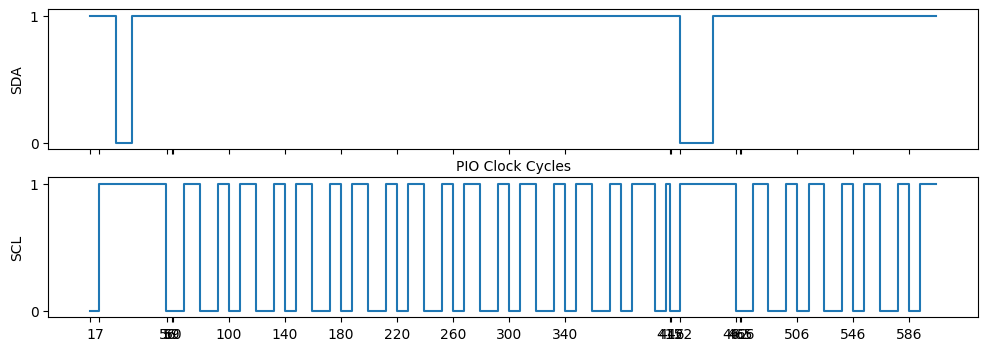

In [94]:
t = [clock for clock, _, _ in trace]

execution = [x[2] for x in trace]
crossref = {value:key for key,value in asm.public_labels.items()}
execution = [crossref[x] if x in crossref else x for x in execution]

def binary_plot(names):
    n = len(names)
    fig, axes = plt.subplots(n,1,sharex=True,sharey=True, figsize=(12,4))
    for i in range(n):
        axes[i].step(t,  [1 if logic_level&(1<<i) else 0 for _, logic_level, _ in trace])
        axes[i].set_ylabel(names[i])
    axes[0].set_xlabel('PIO Clock Cycles')
    plt.yticks([0,1])
    plt.xticks([n for n,e in zip(t,execution) if type(e) is type('')]) #Only label the named transitions

binary_plot(['SDA','SCL'])

In [56]:
execution

['entry_point',
 13,
 14,
 15,
 16,
 17,
 'do_start',
 19,
 20,
 21,
 22,
 'entry_point',
 13,
 14,
 'do_byte',
 'bitloop',
 4,
 5,
 6,
 7,
 'bitloop',
 4,
 5,
 6,
 7,
 'bitloop',
 4,
 5,
 6,
 7,
 'bitloop',
 4,
 5,
 6,
 7,
 'bitloop',
 4,
 5,
 6,
 7,
 'bitloop',
 4,
 5,
 6,
 7,
 'bitloop',
 4,
 5,
 6,
 7,
 'bitloop',
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 'do_nack',
 1]